In [33]:
import pandas as pd # lirary that is used to read and handle data from .csv file
import numpy as np # library that is used for mathematical calculations and arrays
import matplotlib.pyplot as plt # library used for Basic Charts / Graphs
import seaborn as sns # library used for STATISTICAL Basic Charts / Graphs


In [34]:
df=pd.read_csv("Nassau Candy Distributor.csv") #pandas reading .csv
#df.head() # showing first 5 cells o dataset

In [35]:
df.shape # gives you no. of rows and columns

(10194, 18)

In [36]:
df.columns # gives you your columns from dataset

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='object')

In [37]:
df.dtypes # gives you data types of your data

Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID         int64
Country/Region     object
City               object
State/Province     object
Postal Code        object
Division           object
Region             object
Product ID         object
Product Name       object
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object

In [38]:
df.isnull().sum() # gives you null/blank values in your dataset

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [39]:
df.describe() #gives you basic statistics of your dataset

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [40]:
df['Ship Mode'].value_counts() #gives you disttribution of Shiop mode cell(E) 

Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64

In [41]:
df['Country/Region'].value_counts() #gives you disttribution of Contry/Region cell(G) 

Country/Region
United States    9994
Canada            200
Name: count, dtype: int64

In [48]:
#  Region Distribution
df['Region'].value_counts()

Region
Pacific     3253
Atlantic    2986
Interior    2335
Gulf        1620
Name: count, dtype: int64

In [49]:
#  Division Distribution
df['Division'].value_counts()

Division
Chocolate    9844
Other         310
Sugar          40
Name: count, dtype: int64

In [50]:
#Product Distribution
df['Product Name'].value_counts()

Product Name
Wonka Bar - Milk Chocolate           2137
Wonka Bar -Scrumdiddlyumptious       2064
Wonka Bar - Triple Dazzle Caramel    2015
Wonka Bar - Fudge Mallows            1818
Wonka Bar - Nutty Crunch Surprise    1810
Wonka Gum                             120
Kazookles                              96
Lickable Wallpaper                     94
Laffy Taffy                            10
SweeTARTS                              10
Fizzy Lifting Drinks                    6
Nerds                                   4
Hair Toffee                             4
Everlasting Gobstopper                  3
Fun Dip                                 3
Name: count, dtype: int64

In [52]:
# Calculate Lead Time (FIXED)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')
df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Lead Time'].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time, dtype: float64

In [53]:
df.groupby('Ship Mode')['Lead Time'].mean().round(2) #Groups all orders by Ship Mode, Calculates average lead time for each shipping method ,Helps us see which shipping mode is fastest vs slowest

Ship Mode
First Class       1338.28
Same Day          1333.44
Second Class      1323.85
Standard Class    1314.33
Name: Lead Time, dtype: float64

In [54]:
df.groupby('Region')['Lead Time'].mean().round(2)

Region
Atlantic    1322.75
Gulf        1311.37
Interior    1323.09
Pacific     1322.19
Name: Lead Time, dtype: float64

In [55]:
df.groupby('Product Name')['Lead Time'].mean().round(2).sort_values(ascending=False)

Product Name
Hair Toffee                          1455.25
Everlasting Gobstopper               1394.67
SweeTARTS                            1383.50
Laffy Taffy                          1383.10
Lickable Wallpaper                   1339.14
Wonka Bar - Nutty Crunch Surprise    1328.92
Wonka Bar - Triple Dazzle Caramel    1325.66
Wonka Bar -Scrumdiddlyumptious       1320.64
Wonka Bar - Milk Chocolate           1316.76
Wonka Bar - Fudge Mallows            1314.24
Wonka Gum                            1306.53
Nerds                                1274.00
Fizzy Lifting Drinks                 1273.50
Kazookles                            1272.99
Fun Dip                              1272.67
Name: Lead Time, dtype: float64

In [56]:
df.groupby('Division')['Lead Time'].mean().round(2)

Division
Chocolate    1321.17
Other        1306.03
Sugar        1355.65
Name: Lead Time, dtype: float64

In [57]:
df.groupby('Division')['Gross Profit'].mean().round(2)

Division
Chocolate     9.02
Other        13.98
Sugar         7.12
Name: Gross Profit, dtype: float64

In [58]:
df.groupby('Product Name')['Gross Profit'].mean().round(2).sort_values(ascending=False)

Product Name
Lickable Wallpaper                   41.81
Everlasting Gobstopper               34.67
Hair Toffee                          14.88
Wonka Bar -Scrumdiddlyumptious        9.38
Wonka Bar - Nutty Crunch Surprise     9.29
Wonka Bar - Triple Dazzle Caramel     9.24
Wonka Bar - Fudge Mallows             9.13
Wonka Bar - Milk Chocolate            8.16
Fizzy Lifting Drinks                  7.88
Laffy Taffy                           3.35
SweeTARTS                             2.87
Wonka Gum                             2.59
Nerds                                 1.75
Fun Dip                               1.60
Kazookles                             0.97
Name: Gross Profit, dtype: float64

In [59]:
df.groupby('Region')['Gross Profit'].mean().round(2)

Region
Atlantic    9.03
Gulf        9.07
Interior    9.11
Pacific     9.37
Name: Gross Profit, dtype: float64

In [60]:
df.groupby('Ship Mode')['Gross Profit'].mean().round(2)

Ship Mode
First Class       9.05
Same Day          8.59
Second Class      9.25
Standard Class    9.22
Name: Gross Profit, dtype: float64

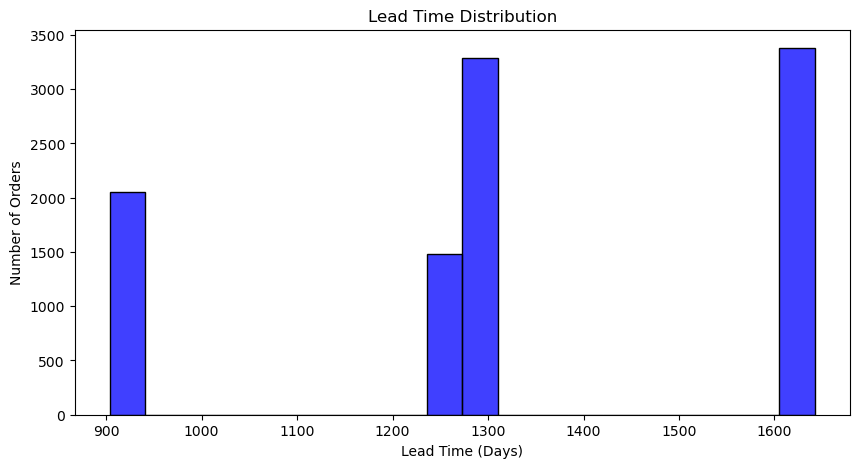

In [61]:
# Lead Time Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Lead Time'], bins=20, color='blue')
plt.title('Lead Time Distribution')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Number of Orders')
plt.show()

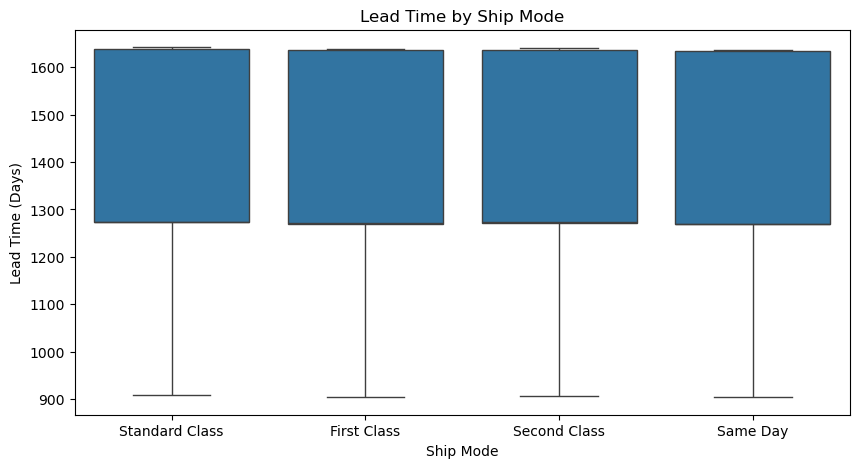

In [62]:
# Lead Time by Ship Mode
plt.figure(figsize=(10,5))
sns.boxplot(x='Ship Mode', y='Lead Time', data=df)
plt.title('Lead Time by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Lead Time (Days)')
plt.show()

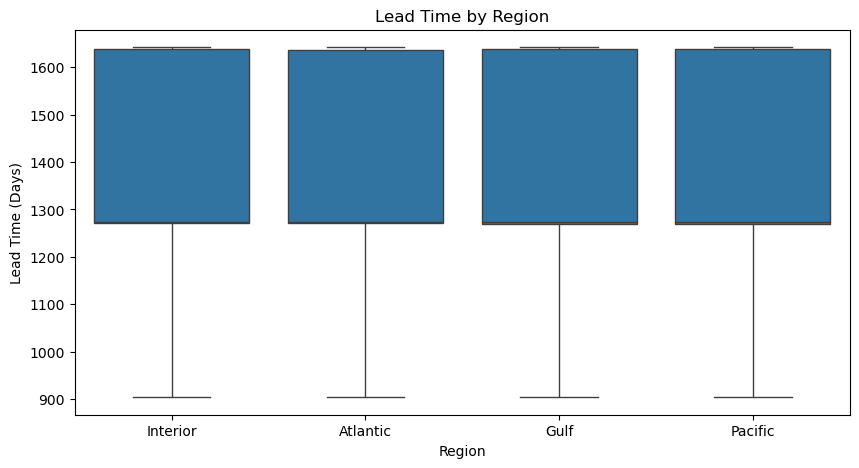

In [63]:
# Lead Time by Region
plt.figure(figsize=(10,5))
sns.boxplot(x='Region', y='Lead Time', data=df)
plt.title('Lead Time by Region')
plt.xlabel('Region')
plt.ylabel('Lead Time (Days)')
plt.show()

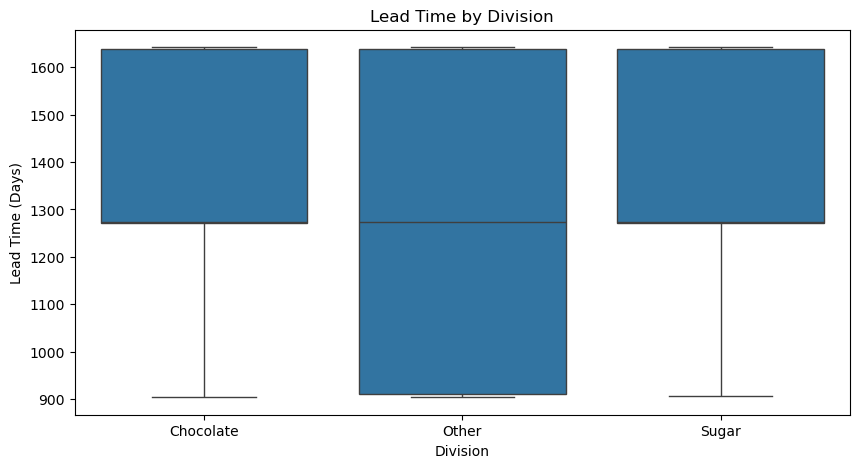

In [69]:
#  Lead Time by Division
plt.figure(figsize=(10,5))
sns.boxplot(x='Division', y='Lead Time', data=df)
plt.title('Lead Time by Division')
plt.xlabel('Division')
plt.ylabel('Lead Time (Days)')
plt.show()

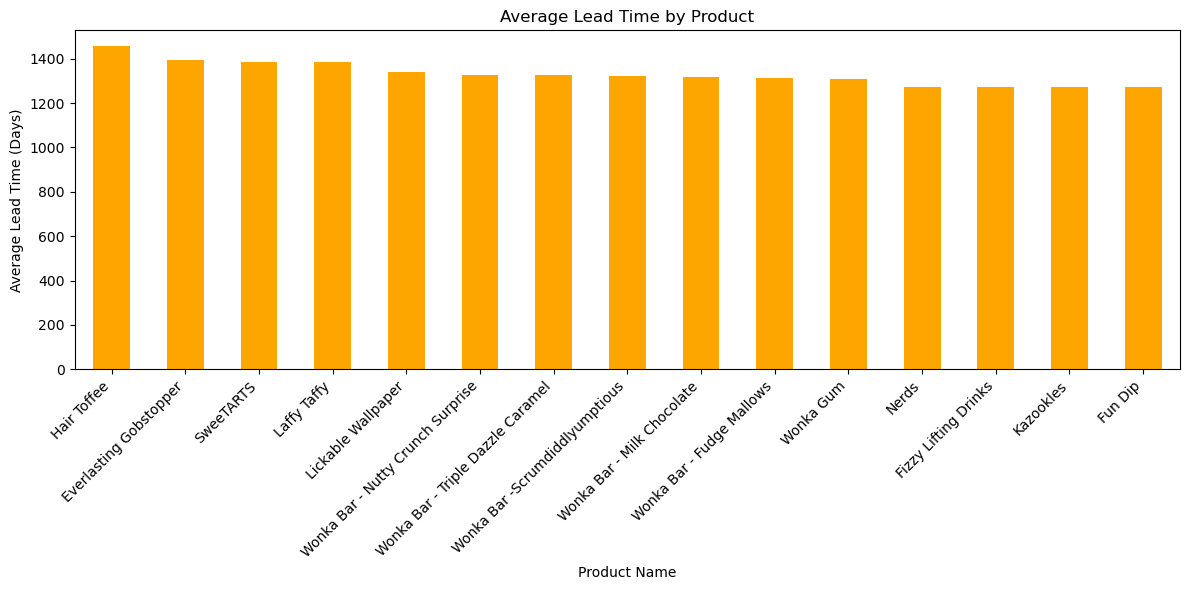

In [68]:
# Average Lead Time by Product
plt.figure(figsize=(12,6))
df.groupby('Product Name')['Lead Time'].mean().sort_values(ascending=False).plot(kind='bar', color='orange')
plt.title('Average Lead Time by Product')
plt.xlabel('Product Name')
plt.ylabel('Average Lead Time (Days)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

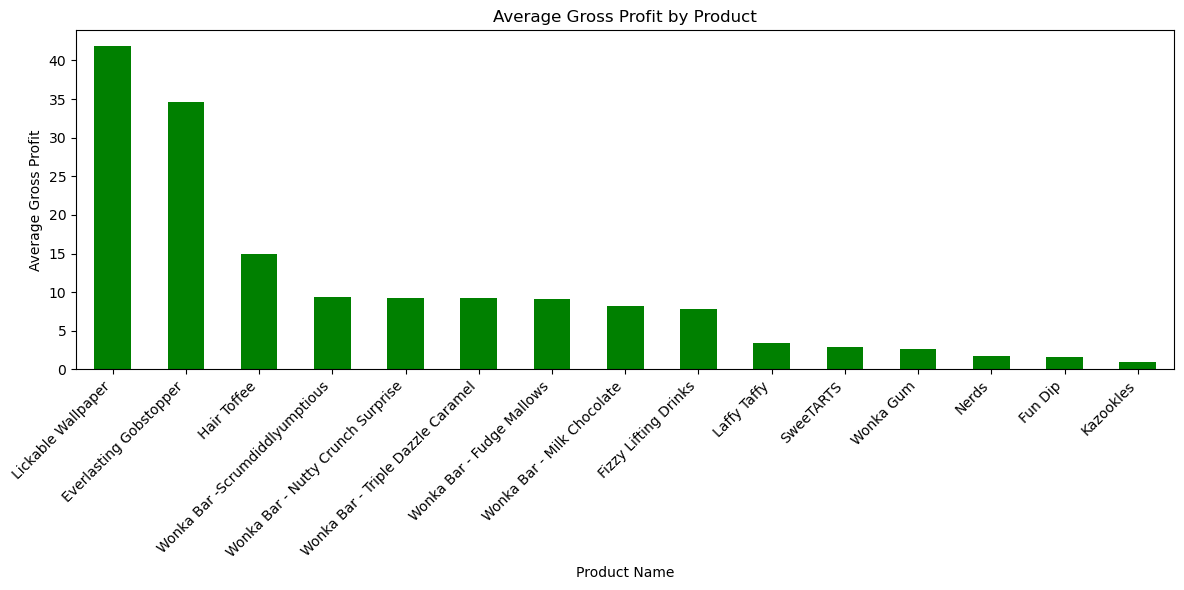

In [67]:
#Average Profit by Product
plt.figure(figsize=(12,6))
df.groupby('Product Name')['Gross Profit'].mean().sort_values(ascending=False).plot(kind='bar', color='green')
plt.title('Average Gross Profit by Product')
plt.xlabel('Product Name')
plt.ylabel('Average Gross Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [70]:
# Phase 1 is complete 

In [71]:
# Adding Factory column based on Product-Factory mapping
factory_map = {
    'Wonka Bar - Nutty Crunch Surprise': "Lot's O' Nuts",
    'Wonka Bar - Fudge Mallows': "Lot's O' Nuts",
    'Wonka Bar -Scrumdiddlyumptious': "Lot's O' Nuts",
    'Wonka Bar - Milk Chocolate': "Wicked Choccy's",
    'Wonka Bar - Triple Dazzle Caramel': "Wicked Choccy's",
    'Laffy Taffy': 'Sugar Shack',
    'SweeTARTS': 'Sugar Shack',
    'Nerds': 'Sugar Shack',
    'Fun Dip': 'Sugar Shack',
    'Fizzy Lifting Drinks': 'Sugar Shack',
    'Everlasting Gobstopper': 'Secret Factory',
    'Hair Toffee': 'The Other Factory',
    'Lickable Wallpaper': 'Secret Factory',
    'Wonka Gum': 'Secret Factory',
    'Kazookles': 'The Other Factory'
}

df['Factory'] = df['Product Name'].map(factory_map)
df[['Product Name', 'Factory']].head(10)

#Creates a new column called Factory and Maps each product to its factory based on the project documentation

,Product Name,Factory
0,Wonka Bar - Milk Chocolate,Wicked Choccy's
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
5,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
7,Wonka Bar - Milk Chocolate,Wicked Choccy's
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
9,Wonka Bar - Milk Chocolate,Wicked Choccy's


In [72]:
# Encoding categorical columns into numbers for ML
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Ship Mode Encoded'] = le.fit_transform(df['Ship Mode'])
df['Region Encoded'] = le.fit_transform(df['Region'])
df['Factory Encoded'] = le.fit_transform(df['Factory'])
df['Division Encoded'] = le.fit_transform(df['Division'])

# Preview the encoded columns
df[['Ship Mode', 'Ship Mode Encoded', 
    'Region', 'Region Encoded',
    'Factory', 'Factory Encoded']].head(10)

,Ship Mode,Ship Mode Encoded,Region,Region Encoded,Factory,Factory Encoded
0,Standard Class,3,Interior,2,Wicked Choccy's,4
1,Standard Class,3,Interior,2,Wicked Choccy's,4
2,Standard Class,3,Interior,2,Lot's O' Nuts,0
3,Standard Class,3,Interior,2,Lot's O' Nuts,0
4,Standard Class,3,Atlantic,0,Wicked Choccy's,4
5,Standard Class,3,Gulf,1,Lot's O' Nuts,0
6,Standard Class,3,Gulf,1,Wicked Choccy's,4
7,First Class,0,Gulf,1,Wicked Choccy's,4
8,Standard Class,3,Gulf,1,Lot's O' Nuts,0
9,Standard Class,3,Gulf,1,Wicked Choccy's,4


In [73]:
# Encoding categorical columns into numbers for ML
from sklearn.preprocessing import LabelEncoder

# LabelEncoder converts text categories into numbers
# Example: "Standard Class"=3, "First Class"=0, "Same Day"=2, "Second Class"=1
le = LabelEncoder() # creating a LabelEncoder tool

# fit_transform = learns all unique values and converts them to numbers
df['Ship Mode Encoded'] = le.fit_transform(df['Ship Mode']) # Standard Class=3, First Class=0 etc
df['Region Encoded'] = le.fit_transform(df['Region']) # Atlantic=0, Gulf=1, Interior=2, Pacific=3
df['Factory Encoded'] = le.fit_transform(df['Factory']) # each factory gets a number 0-4
df['Division Encoded'] = le.fit_transform(df['Division']) # Chocolate=0, Other=1, Sugar=2

# Preview to verify encoding worked correctly
df[['Ship Mode', 'Ship Mode Encoded', 
    'Region', 'Region Encoded',
    'Factory', 'Factory Encoded']].head(10)

,Ship Mode,Ship Mode Encoded,Region,Region Encoded,Factory,Factory Encoded
0,Standard Class,3,Interior,2,Wicked Choccy's,4
1,Standard Class,3,Interior,2,Wicked Choccy's,4
2,Standard Class,3,Interior,2,Lot's O' Nuts,0
3,Standard Class,3,Interior,2,Lot's O' Nuts,0
4,Standard Class,3,Atlantic,0,Wicked Choccy's,4
5,Standard Class,3,Gulf,1,Lot's O' Nuts,0
6,Standard Class,3,Gulf,1,Wicked Choccy's,4
7,First Class,0,Gulf,1,Wicked Choccy's,4
8,Standard Class,3,Gulf,1,Lot's O' Nuts,0
9,Standard Class,3,Gulf,1,Wicked Choccy's,4


In [76]:
# Import train_test_split
from sklearn.model_selection import train_test_split
# Selecting features (X) and target (y) for ML model
# X = inputs we give the model
# y = what we want the model to predict

X = df[['Ship Mode Encoded', 'Region Encoded', 
        'Factory Encoded', 'Division Encoded', 
        'Units', 'Sales', 'Cost']]  # features

y = df['Lead Time']  # target we want to predict

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)  # 80% of data
print("Testing size:", X_test.shape)    # 20% of data

# 8,155 rows → model learns from these (80%)
# 2,039 rows → we test accuracy on these (20%)
# 7 columns → our 7 features (Ship Mode, Region, Factory, Division, Units, Sales, Cost)

Training size: (8155, 7)
Testing size: (2039, 7)


In [77]:
#TRAINING ML MODEL 

# Import all ML models and metrics
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train Linear Regression (baseline model)
lr_model = LinearRegression() # create model
lr_model.fit(X_train, y_train) # train model
lr_pred = lr_model.predict(X_test) # make predictions

# Evaluate model
print("LINEAR REGRESSION RESULTS:")
print("MAE :", round(mean_absolute_error(y_test, lr_pred), 2))
print("RMSE:", round(mean_squared_error(y_test, lr_pred)**0.5, 2))
print("R2  :", round(r2_score(y_test, lr_pred), 2))

LINEAR REGRESSION RESULTS:
MAE : 215.04
RMSE: 266.14
R2  : -0.0


In [78]:
# Is this good or bad?

#This is a BAD result!
# R2 of 0.0 means the model learned nothing
# It's as good as just guessing the average every time
# Linear Regression is too simple for our data

In [79]:
# RUNNING RANDOM FOREST 
# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)  # train model
rf_pred = rf_model.predict(X_test)  # make predictions

# Evaluate model
print("RANDOM FOREST RESULTS:")
print("MAE :", round(mean_absolute_error(y_test, rf_pred), 2))
print("RMSE:", round(mean_squared_error(y_test, rf_pred)**0.5, 2))
print("R2  :", round(r2_score(y_test, rf_pred), 2))

RANDOM FOREST RESULTS:
MAE : 225.04
RMSE: 277.24
R2  : -0.09


In [80]:
# Both models are struggling!

In [81]:
# Train Gradient Boosting model
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)  # train model
gb_pred = gb_model.predict(X_test)  # make predictions

# Evaluate model
print("GRADIENT BOOSTING RESULTS:")
print("MAE :", round(mean_absolute_error(y_test, gb_pred), 2))
print("RMSE:", round(mean_squared_error(y_test, gb_pred)**0.5, 2))
print("R2  :", round(r2_score(y_test, gb_pred), 2))

GRADIENT BOOSTING RESULTS:
MAE : 215.78
RMSE: 267.6
R2  : -0.01


In [82]:
# Comparing all 3 models together
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE': [
        round(mean_absolute_error(y_test, lr_pred), 2),
        round(mean_absolute_error(y_test, rf_pred), 2),
        round(mean_absolute_error(y_test, gb_pred), 2)
    ],
    'RMSE': [
        round(mean_squared_error(y_test, lr_pred)**0.5, 2),
        round(mean_squared_error(y_test, rf_pred)**0.5, 2),
        round(mean_squared_error(y_test, gb_pred)**0.5, 2)
    ],
    'R2': [
        round(r2_score(y_test, lr_pred), 2),
        round(r2_score(y_test, rf_pred), 2),
        round(r2_score(y_test, gb_pred), 2)
    ]
})
print(results)

               Model     MAE    RMSE    R2
0  Linear Regression  215.04  266.14 -0.00
1      Random Forest  225.04  277.24 -0.09
2  Gradient Boosting  215.78  267.60 -0.01


In [83]:
# Linear regression is a better model among all 3

In [84]:
# Calculate actual average lead time per factory
factory_avg_leadtime = df.groupby('Factory')['Lead Time'].mean().round(2)
print("Average Lead Time per Factory:")
print(factory_avg_leadtime)

Average Lead Time per Factory:
Factory
Lot's O' Nuts        1321.23
Secret Factory       1321.87
Sugar Shack          1340.03
The Other Factory    1280.28
Wicked Choccy's      1321.08
Name: Lead Time, dtype: float64


In [85]:
# RUNNING RECOMMENDATION ENGINE 

# Recommendation Engine based on actual factory performance
factory_avg_leadtime = df.groupby('Factory')['Lead Time'].mean()
factory_avg_profit = df.groupby('Factory')['Gross Profit'].mean()

recommendations = []

for product in df['Product Name'].unique():
    product_df = df[df['Product Name'] == product]
    current_factory = product_df['Factory'].iloc[0]
    current_lead_time = product_df['Lead Time'].mean()
    current_profit = product_df['Gross Profit'].mean()

    # Find best factory by lead time
    best_factory = factory_avg_leadtime.idxmin()
    best_lead_time = factory_avg_leadtime.min()
    improvement = round(current_lead_time - best_lead_time, 2)

    recommendations.append({
        'Product': product,
        'Current Factory': current_factory,
        'Recommended Factory': best_factory,
        'Current Lead Time': round(current_lead_time, 2),
        'Predicted Lead Time': round(best_lead_time, 2),
        'Improvement (Days)': improvement,
        'Avg Gross Profit': round(current_profit, 2)
    })

recommendations_df = pd.DataFrame(recommendations)
recommendations_df.sort_values('Improvement (Days)', ascending=False)

,Product,Current Factory,Recommended Factory,Current Lead Time,Predicted Lead Time,Improvement (Days),Avg Gross Profit
12,Hair Toffee,The Other Factory,The Other Factory,1455.25,1280.28,174.97,14.88
13,Everlasting Gobstopper,Secret Factory,The Other Factory,1394.67,1280.28,114.39,34.67
10,SweeTARTS,Sugar Shack,The Other Factory,1383.50,1280.28,103.22,2.87
9,Laffy Taffy,Sugar Shack,The Other Factory,1383.10,1280.28,102.82,3.35
7,Lickable Wallpaper,Secret Factory,The Other Factory,1339.14,1280.28,58.86,41.81
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,The Other Factory,1328.92,1280.28,48.64,9.29
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,The Other Factory,1325.66,1280.28,45.38,9.24
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,The Other Factory,1320.64,1280.28,40.36,9.38
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,1316.76,1280.28,36.48,8.16
4,Wonka Bar - Fudge Mallows,Lot's O' Nuts,The Other Factory,1314.24,1280.28,33.96,9.13


In [86]:
# Save recommendations to CSV
recommendations_df.to_csv('recommendations.csv', index=False)
print("Recommendations saved! ✅")

Recommendations saved! ✅
